# Phần 1: Khám phá Dữ liệu (EDA) & Tiền xử lý Dữ liệu
**Người thực hiện:** Anh Hào  
**Dữ liệu:** Diamonds Dataset (data/raw/diamonds.csv -> data/processed/cleaned_diamonds.csv)  
**Mục tiêu:** Khảo sát cấu trúc, tiền xử lý và làm sạch dữ liệu, phân tích thống kê mô tả, trực quan hóa xu hướng dữ liệu với ít nhất 3 loại biểu đồ phù hợp, và phát hiện - đề xuất phương án xử lý ngoại lai.

---

## 1. Thiết lập Môi trường & Cấu hình Thư viện
Nạp các thư viện phân tích dữ liệu chuyên nghiệp trong hệ sinh thái Python (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`), đồng thời đồng bộ hóa quy chuẩn hiển thị biểu đồ của cả nhóm từ module dùng chung `src.utils`.

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

# Bỏ qua các cảnh báo không cần thiết để báo cáo sạch sẽ
warnings.filterwarnings('ignore')

# Thiết lập hiển thị số thực trên pandas
pd.set_option('display.float_format', lambda x: '%.4f' % x)
pd.set_option('display.max_columns', 15)

# Cố định seed cho tính tái lập (Reproducibility)
np.random.seed(42)

# Import module dùng chung của nhóm
sys.path.append('..')
from src.utils import set_plotting_style

# Kích hoạt style chuẩn của toàn dự án
set_plotting_style()

# Thiết lập đường dẫn các thư mục dự án
RAW_DATA_PATH = os.path.join('..', 'data', 'raw', 'diamonds.csv')
PROCESSED_DATA_PATH = os.path.join('..', 'data', 'processed', 'cleaned_diamonds.csv')
FIGURES_DIR = os.path.join('..', 'figures', 'part1_eda')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(os.path.dirname(PROCESSED_DATA_PATH), exist_ok=True)

print(">> Môi trường phân tích và cấu hình hệ thống đã sẵn sàng!")
print(f">> Đường dẫn file dữ liệu thô: {RAW_DATA_PATH}")
print(f">> Thư mục lưu biểu đồ chất lượng cao: {FIGURES_DIR}")


>> Môi trường phân tích và cấu hình hệ thống đã sẵn sàng!
>> Đường dẫn file dữ liệu thô: ..\data\raw\diamonds.csv
>> Thư mục lưu biểu đồ chất lượng cao: ..\figures\part1_eda


## 2. Tải Dữ liệu & Đánh giá Sơ bộ Cấu trúc (Data Loading & Inspection)

### Ý nghĩa thực tế của các thuộc tính trong Bộ dữ liệu Kim cương (Diamonds Dataset)
Bộ dữ liệu gồm 10 thuộc tính đặc trưng phản ánh giá trị và đặc tính vật lý của kim cương theo tiêu chuẩn quốc tế **4C** của Viện Đá quý Hoa Kỳ (GIA):
1. **`carat`**: Trọng lượng của viên kim cương ($1\text{ carat} = 0.2\text{ gram}$). Đây là yếu tố quan trọng nhất quyết định kích thước và giá thành.
2. **`cut`**: Chất lượng giác cắt, phản ánh khả năng phản xạ ánh sáng tạo độ lấp lánh. Gồm 5 cấp độ (xếp từ thấp đến cao): `Fair` < `Good` < `Very Good` < `Premium` < `Ideal`.
3. **`color`**: Thang đo màu sắc, đánh giá từ không màu (tốt nhất) đến có sắc vàng nhẹ (kém hơn). Thang đo từ `J` (kém nhất trong mẫu) đến `D` (hoàn toàn không màu - cao cấp nhất).
4. **`clarity`**: Độ tinh khiết, đo lường các vết nứt và tạp chất bên trong và ngoài viên kim cương. Thứ tự từ thấp đến cao: `I1` (Included) < `SI2`, `SI1` (Slightly Included) < `VS2`, `VS1` (Very Slightly Included) < `VVS2`, `VVS1` (Very Very Slightly Included) < `IF` (Internally Flawless).
5. **`depth`**: Tỷ lệ phần trăm chiều sâu tổng thể, tính theo công thức: $\text{depth} = \frac{2z}{x + y} \times 100\%$.
6. **`table`**: Chiều rộng của mặt cắt trên cùng (table) so với đường kính rộng nhất của viên kim cương (tính theo %).
7. **`price`**: Giá bán thực tế bằng Đô la Mỹ ($USD) – Đây là **biến mục tiêu (Target variable)** chính của các mô hình phân tích và dự báo.
8. **`x`**: Chiều dài của viên kim cương tính bằng milimét ($mm$).
9. **`y`**: Chiều rộng của viên kim cương tính bằng milimét ($mm$).
10. **`z`**: Chiều sâu của viên kim cương tính bằng milimét ($mm$).

In [2]:
# 1. Đọc dữ liệu thô từ file CSV
df_raw = pd.read_csv(RAW_DATA_PATH)

print(f"Tổng số bản ghi ban đầu: {df_raw.shape[0]:,} dòng")
print(f"Tổng số thuộc tính: {df_raw.shape[1]} cột")

# Hiển thị 5 dòng đầu tiên
print()
print("--- 5 DÒNG ĐẦU TIÊN CỦA TẬP DỮ LIỆU ---")
display(df_raw.head())

# Hiển thị thông tin kiểu dữ liệu và bộ nhớ
print()
print("--- THÔNG TIN CẤU TRÚC DỮ LIỆU (INFO) ---")
df_raw.info()


Tổng số bản ghi ban đầu: 53,940 dòng
Tổng số thuộc tính: 11 cột

--- 5 DÒNG ĐẦU TIÊN CỦA TẬP DỮ LIỆU ---


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.2300,Ideal,E,SI2,61.5000,55.0000,326,3.9500,3.9800,2.4300
1,2,0.2100,Premium,E,SI1,59.8000,61.0000,326,3.8900,3.8400,2.3100
2,3,0.2300,Good,E,VS1,56.9000,65.0000,327,4.0500,4.0700,2.3100
3,4,0.2900,Premium,I,VS2,62.4000,58.0000,334,4.2000,4.2300,2.6300
4,5,0.3100,Good,J,SI2,63.3000,58.0000,335,4.3400,4.3500,2.7500



--- THÔNG TIN CẤU TRÚC DỮ LIỆU (INFO) ---
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  str    
 3   color       53940 non-null  str    
 4   clarity     53940 non-null  str    
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), str(3)
memory usage: 4.5 MB


### Nhận xét sơ bộ từ bước Khảo sát cấu trúc:
1. Tập dữ liệu thô bao gồm **53,940 dòng** và **11 cột**.
2. Xuất hiện cột `Unnamed: 0` – Đây là cột chỉ mục (index) cũ tự động sinh ra trong quá trình xuất file CSV, hoàn toàn không mang ý nghĩa nghiệp vụ và cần được loại bỏ.
3. Dữ liệu gồm:
   - **3 biến định tính (Categorical):** `cut`, `color`, `clarity` (dạng text - object).
   - **7 biến định lượng (Numerical):** `carat`, `depth`, `table`, `price`, `x`, `y`, `z` (dạng int64 và float64).
4. Để đảm bảo chất lượng nghiên cứu, phần tiếp theo sẽ tiến hành quy trình làm sạch từng bước có đối chiếu nhận xét ngay bên dưới mỗi kết quả.

## 3. Tiền xử lý & Làm sạch Dữ liệu (Data Preprocessing & Cleaning)

Quy trình tiền xử lý được chia nhỏ thành các bước độc lập. Mỗi bước đều có phần hiển thị kết quả kiểm tra (Code) và nhận xét phân tích chuyên môn (Markdown) ngay liền kề bên dưới để tiện theo dõi:
- **Bước 3.1:** Loại bỏ cột định danh thừa (`Unnamed: 0`).
- **Bước 3.2:** Rà soát giá trị khuyết thiếu (Missing Values).
- **Bước 3.3:** Phát hiện và loại bỏ các bản ghi trùng lặp (Duplicate Records).
- **Bước 3.4:** Rà soát và xử lý lỗi logic kích thước vật lý ($x, y, z \le 0$).
- **Bước 3.5:** Rà soát và xử lý các giá trị dị biệt kích thước cực đoan ($y > 20\text{ mm}$ hoặc $z > 20\text{ mm}$).
- **Bước 3.6:** Chuẩn hóa kiểu dữ liệu có thứ tự (Ordinal Categorical Encoding).
- **Bước 3.7:** Tổng kết nghiệm thu toàn bộ quá trình tiền xử lý.

### Bước 3.1: 
Loại bỏ Cột Định danh Thừa (Unnamed: 0)

In [3]:
df_clean = df_raw.copy()

if 'Unnamed: 0' in df_clean.columns:
    df_clean.drop(columns=['Unnamed: 0'], inplace=True)
    print(">> [ĐÃ XÓA] Cột định danh thừa 'Unnamed: 0'.")

print(f">> Danh sách các thuộc tính còn lại ({df_clean.shape[1]} cột):")
print(list(df_clean.columns))


>> [ĐÃ XÓA] Cột định danh thừa 'Unnamed: 0'.
>> Danh sách các thuộc tính còn lại (10 cột):
['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']


### Nhận xét Bước 3.1:
Cột `Unnamed: 0` là chỉ số dòng từ lần lưu CSV trước đó, hoàn toàn không mang thông tin đặc trưng của viên kim cương. Việc xóa cột này giúp giải phóng bộ nhớ và ngăn ngừa các thuật toán học máy hiểu nhầm đây là một biến độc lập số học.

### Bước 3.2: 
Rà soát Giá trị Khuyết thiếu (Missing Values)

In [4]:
missing_df = pd.DataFrame({
    'Số lượng khuyết (NaN)': df_clean.isnull().sum(),
    'Tỷ lệ khuyết (%)': (df_clean.isnull().sum() / len(df_clean)) * 100
})

print("--- BẢNG KIỂM TRA GIÁ TRỊ KHUYẾT THIẾU ---")
display(missing_df)


--- BẢNG KIỂM TRA GIÁ TRỊ KHUYẾT THIẾU ---


,Số lượng khuyết (NaN),Tỷ lệ khuyết (%)
carat,0,0.0000
cut,0,0.0000
color,0,0.0000
clarity,0,0.0000
depth,0,0.0000
table,0,0.0000
price,0,0.0000
x,0,0.0000
y,0,0.0000
z,0,0.0000


### Nhận xét Bước 3.2:
Tập dữ liệu đạt tỷ lệ khuyết **$0.00\%$** trên toàn bộ 10 thuộc tính (không có bất kỳ giá trị `NaN` nào). Dữ liệu có tính toàn vẹn hoàn hảo về mặt cấu trúc bảng.

### Bước 3.3: 
Phát hiện và Loại bỏ Dữ liệu Trùng lặp (Duplicate Records)

In [5]:
n_duplicates = df_clean.duplicated().sum()
print(f">> Số lượng bản ghi trùng lặp phát hiện: {n_duplicates} dòng ({n_duplicates/len(df_clean)*100:.3f}%)")

if n_duplicates > 0:
    dup_samples = df_clean[df_clean.duplicated(keep=False)].sort_values(by=['carat', 'cut', 'price']).head(6)
    print()
    print("Ví dụ một số cặp bản ghi trùng lặp thông số hoàn toàn:")
    display(dup_samples)
    
    df_clean.drop_duplicates(inplace=True)
    df_clean.reset_index(drop=True, inplace=True)
    print(f">> [ĐÃ LOẠI BỎ] {n_duplicates} dòng trùng lặp. Kích thước dữ liệu hiện tại: {df_clean.shape[0]:,} dòng.")


>> Số lượng bản ghi trùng lặp phát hiện: 146 dòng (0.271%)

Ví dụ một số cặp bản ghi trùng lặp thông số hoàn toàn:


,carat,cut,color,clarity,depth,table,price,x,y,z
43995,0.3000,Good,J,VS1,63.4000,57.0000,394,4.2300,4.2600,2.6900
47296,0.3000,Good,J,VS1,63.4000,57.0000,394,4.2300,4.2600,2.6900
31624,0.3000,Ideal,H,SI1,62.2000,57.0000,450,4.2600,4.2900,2.6600
31626,0.3000,Ideal,H,SI1,62.2000,57.0000,450,4.2700,4.2800,2.6600
31627,0.3000,Ideal,H,SI1,62.2000,57.0000,450,4.2600,4.2900,2.6600
31629,0.3000,Ideal,H,SI1,62.2000,57.0000,450,4.2700,4.2800,2.6600


>> [ĐÃ LOẠI BỎ] 146 dòng trùng lặp. Kích thước dữ liệu hiện tại: 53,794 dòng.


### Nhận xét Bước 3.3:
Phát hiện và loại bỏ **146 bản ghi trùng lặp** $100\%$ về mọi thuộc tính. Việc loại bỏ các dòng này là cần thiết để tránh việc nhân đôi trọng số nhân tạo, giúp phản ánh trung thực phân phối xác suất và ngăn chặn sự thiên vị (bias) trong các mô hình kiểm định thống kê và hồi quy sau này.

### Bước 3.4: 
Rà soát và Xử lý Lỗi Logic Kích thước Vật lý (x, y, z <= 0)

In [6]:
zero_dim_mask = (df_clean['x'] <= 0) | (df_clean['y'] <= 0) | (df_clean['z'] <= 0)
n_zero_dim = zero_dim_mask.sum()
print(f">> Tổng số bản ghi có kích thước vật lý <= 0: {n_zero_dim} dòng ({n_zero_dim/len(df_clean)*100:.3f}%)")
print()

# Phân loại thành 2 nhóm: Nhóm chỉ thiếu z vs Nhóm thiếu từ 2 biến trở lên
z_only_zero_mask = (df_clean['z'] <= 0) & (df_clean['x'] > 0) & (df_clean['y'] > 0)
multi_zero_mask = zero_dim_mask & (~z_only_zero_mask)

print(f"1. Nhóm thiếu từ 2 biến kích thước trở lên (ví dụ: x=0 và z=0): {multi_zero_mask.sum()} bản ghi")
print("   -> Không thể giải phương trình hình học để tìm biến khuyết:")
display(df_clean[multi_zero_mask].head(7))

print()
print(f"2. Nhóm chỉ thiếu duy nhất biến z (x > 0, y > 0, depth > 0): {z_only_zero_mask.sum()} bản ghi")
print("   -> Minh họa khả năng nội suy z từ công thức: z = (depth * (x + y)) / 200")
z_demo = df_clean[z_only_zero_mask].copy()
z_demo['z_nội_suy'] = (z_demo['depth'] * (z_demo['x'] + z_demo['y'])) / 200
display(z_demo[['carat', 'cut', 'price', 'depth', 'x', 'y', 'z', 'z_nội_suy']].head(6))

# Quyết định loại bỏ toàn bộ 19 bản ghi
df_clean = df_clean[~zero_dim_mask].copy().reset_index(drop=True)
print()
print(f">> [ĐÃ LOẠI BỎ] {n_zero_dim} bản ghi có kích thước <= 0. Kích thước dữ liệu hiện tại: {df_clean.shape[0]:,} dòng.")


>> Tổng số bản ghi có kích thước vật lý <= 0: 19 dòng (0.035%)

1. Nhóm thiếu từ 2 biến kích thước trở lên (ví dụ: x=0 và z=0): 7 bản ghi
   -> Không thể giải phương trình hình học để tìm biến khuyết:


,carat,cut,color,clarity,depth,table,price,x,y,z
11156,1.0700,Ideal,F,SI2,61.6000,56.0000,4954,0.0000,6.6200,0.0000
11935,1.0000,Very Good,H,VS2,63.3000,53.0000,5139,0.0000,0.0000,0.0000
15914,1.1400,Fair,G,VS1,57.5000,67.0000,6381,0.0000,0.0000,0.0000
24464,1.5600,Ideal,G,VS2,62.2000,54.0000,12800,0.0000,0.0000,0.0000
26183,1.2000,Premium,D,VVS1,62.1000,59.0000,15686,0.0000,0.0000,0.0000
27364,2.2500,Premium,H,SI2,62.8000,59.0000,18034,0.0000,0.0000,0.0000
49413,0.7100,Good,F,SI2,64.1000,60.0000,2130,0.0000,0.0000,0.0000



2. Nhóm chỉ thiếu duy nhất biến z (x > 0, y > 0, depth > 0): 12 bản ghi
   -> Minh họa khả năng nội suy z từ công thức: z = (depth * (x + y)) / 200


,carat,cut,price,depth,x,y,z,z_nội_suy
2201,1.0000,Premium,3142,59.1000,6.5500,6.4800,0.0000,3.8504
2308,1.0100,Premium,3167,58.1000,6.6600,6.6000,0.0000,3.8520
4778,1.1000,Premium,3696,63.0000,6.5000,6.4700,0.0000,4.0855
5457,1.0100,Premium,3837,59.2000,6.5000,6.4700,0.0000,3.8391
10145,1.5000,Good,4731,64.0000,7.1500,7.0400,0.0000,4.5408
13570,1.1500,Ideal,5564,59.2000,6.8800,6.8300,0.0000,4.0582



>> [ĐÃ LOẠI BỎ] 19 bản ghi có kích thước <= 0. Kích thước dữ liệu hiện tại: 53,775 dòng.


### Nhận xét Bước 3.4 (Phân tích Logic Kích thước Vật lý):
1. **Bản chất lỗi:** Kim cương là vật thể 3 chiều trong không gian thực. Việc bất kỳ kích thước $x, y, z \le 0$ nào xuất hiện đều là dấu hiệu thiết bị quét quang học 3D bị lỗi ghi nhận tín hiệu.
2. **Đánh giá hai nhóm lỗi:**
   - **Nhóm thiếu $\ge 2$ biến (7 bản ghi):** Có các viên bị $x=0, z=0$ hoặc cả $x=y=z=0$. Phương trình hình học có 2 ẩn số trở lên nên về mặt toán học không thể giải được $\rightarrow$ Bắt buộc phải loại bỏ.
   - **Nhóm chỉ thiếu biến $z$ (12 bản ghi):** Vì $x, y$ và chỉ số $\text{depth}$ có đầy đủ, về lý thuyết ta có thể tính nội suy giá trị $z_{\text{calc}} = \frac{\text{depth} \times (x + y)}{200}$ (kết quả cho ra các con số rất hợp lý từ $3.85 - 5.66\text{ mm}$).
3. **Quyết định xử lý:** Mặc dù có thể nội suy được 12 bản ghi, nhưng số lượng này chỉ chiếm **$0.022\%$** tổng thể dữ liệu (chưa đầy 3 phần vạn). Nhằm bảo đảm tính khách quan thực nghiệm nguyên bản (không đưa dữ liệu nhân tạo vào tập mẫu khi cảm biến trục $z$ đã gặp sự cố), nhóm thống nhất **loại bỏ toàn bộ 19 bản ghi này**.

### Bước 3.5: 
Rà soát và Xử lý Các Giá trị Dị biệt Kích thước Cực đoan (y > 20mm hoặc z > 20mm)

In [7]:
# 1. Bảng đối chứng kích thước của các viên kim cương lớn nhất mẫu nghiên cứu
print("--- BẢNG ĐỐI CHỨNG: KÍCH THƯỚC CỦA CÁC VIÊN KIM CƯƠNG LỚN NHẤT TRONG TẬP DỮ LIỆU ---")
top_carat_df = df_clean.nlargest(5, 'carat')[['carat', 'cut', 'color', 'clarity', 'price', 'depth', 'x', 'y', 'z']]
display(top_carat_df)

largest_carat = top_carat_df['carat'].iloc[0]
largest_x = top_carat_df['x'].iloc[0]
largest_y = top_carat_df['y'].iloc[0]
largest_z = top_carat_df['z'].iloc[0]

print()
print(f">> Quan sát đối chứng:")
print(f"   Viên kim cương lớn nhất tập mẫu ({largest_carat:.2f} carat) có kích thước: dài x = {largest_x:.2f} mm | rộng y = {largest_y:.2f} mm | sâu z = {largest_z:.2f} mm.")
print("   Toàn bộ các viên kim cương lớn nhất đều có kích thước không vượt quá 11 mm.")
print()

# 2. Phát hiện các bản ghi có kích thước bất thường vượt ngưỡng an toàn 20mm
extreme_dim_mask = (df_clean['y'] > 20) | (df_clean['z'] > 20)
n_extreme = extreme_dim_mask.sum()
print(f">> Phát hiện {n_extreme} bản ghi có kích thước vượt ngưỡng bất thường (> 20mm):")
display(df_clean[extreme_dim_mask][['carat', 'cut', 'color', 'price', 'depth', 'x', 'y', 'z']])

# Tiến hành loại bỏ 3 bản ghi bất thường này
df_clean = df_clean[~extreme_dim_mask].copy().reset_index(drop=True)
print()
print(f">> [ĐÃ LOẠI BỎ] {n_extreme} bản ghi dị biệt cực đoan. Kích thước dữ liệu hiện tại: {df_clean.shape[0]:,} dòng.")


--- BẢNG ĐỐI CHỨNG: KÍCH THƯỚC CỦA CÁC VIÊN KIM CƯƠNG LỚN NHẤT TRONG TẬP DỮ LIỆU ---


,carat,cut,color,clarity,price,depth,x,y,z
27336,5.0100,Fair,J,I1,18018,65.5000,10.7400,10.5400,6.9800
27547,4.5000,Fair,J,I1,18531,65.8000,10.2300,10.1600,6.7200
27051,4.1300,Fair,H,I1,17329,64.8000,10.0000,9.8500,6.4300
25928,4.0100,Premium,I,I1,15223,61.0000,10.1400,10.1000,6.1700
25929,4.0100,Premium,J,I1,15223,62.5000,10.0200,9.9400,6.2400



>> Quan sát đối chứng:
   Viên kim cương lớn nhất tập mẫu (5.01 carat) có kích thước: dài x = 10.74 mm | rộng y = 10.54 mm | sâu z = 6.98 mm.
   Toàn bộ các viên kim cương lớn nhất đều có kích thước không vượt quá 11 mm.

>> Phát hiện 3 bản ghi có kích thước vượt ngưỡng bất thường (> 20mm):


,carat,cut,color,price,depth,x,y,z
24003,2.0000,Premium,H,12210,58.9000,8.0900,58.9000,8.0600
48251,0.5100,Very Good,E,1970,61.8000,5.1200,5.1500,31.8000
49030,0.5100,Ideal,E,2075,61.8000,5.1500,31.8000,5.1200



>> [ĐÃ LOẠI BỎ] 3 bản ghi dị biệt cực đoan. Kích thước dữ liệu hiện tại: 53,772 dòng.


### Nhận xét Bước 3.5 (Cơ sở Khoa học Loại bỏ Dị biệt Cực đoan):
1. **Bằng chứng đối chứng thực nghiệm:**
   - Kết quả ở bảng đối chứng trên chỉ ra rằng viên kim cương lớn nhất trong toàn bộ mẫu nghiên cứu (**5.01 carat**) cũng chỉ có kích thước tối đa là **$10.74\text{ mm} \times 10.54\text{ mm} \times 6.98\text{ mm}$**.
   - Đối với các viên kim cương thông thường từ $0.51 - 2.0\text{ carat}$, kích thước chuẩn mực chỉ dao động quanh dải $5.0 - 8.5\text{ mm}$.
2. **Sự mâu thuẫn hình học nội tại (Internal Dimensional Inconsistency):**
   - *Bản ghi có $y = 58.9\text{ mm}$:* Một viên kim cương 2.00 ct có chiều dài $x = 8.09\text{ mm}$ và chiều sâu $z = 8.06\text{ mm}$ thì chiều rộng $y$ không thể gấp hơn 7 lần ($58.9\text{ mm}$ - gần bằng $6\text{ cm}$). Đồng thời, giá trị này mâu thuẫn trực tiếp với công thức tỷ lệ chiều sâu $\text{depth} = 58.9\%$.
   - *Bản ghi có $y = 31.8\text{ mm}$ hoặc $z = 31.8\text{ mm}$:* Ở các viên chỉ nặng $0.51\text{ carat}$, một cạnh lên đến hơn $3\text{ cm}$ là phi lý đối với thể tích và khối lượng riêng của kim cương ($3.51\text{ g/cm}^3$).
3. **Kết luận xử lý:** Các giá trị này là **dữ liệu dị biệt bất khả thi về mặt vật lý (Gross Physical Anomalies)**. Việc loại bỏ 3 bản ghi này dựa trên cơ sở đối chứng thực nghiệm và giới hạn vật lý rõ ràng, giúp bảo vệ biểu đồ không bị kéo dãn trục tọa độ và ngăn ngừa các điểm đòn bẩy làm méo mó mô hình hồi quy.

### Bước 3.6: 
Chuẩn hóa Kiểu Dữ liệu Định tính có Thứ bậc (Ordinal Categories)

In [8]:
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D'] # J là ngả vàng, D là không màu cao cấp nhất
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

df_clean['cut'] = pd.Categorical(df_clean['cut'], categories=cut_order, ordered=True)
df_clean['color'] = pd.Categorical(df_clean['color'], categories=color_order, ordered=True)
df_clean['clarity'] = pd.Categorical(df_clean['clarity'], categories=clarity_order, ordered=True)

print(">> Kiểm tra kiểu dữ liệu sau khi gán thứ bậc:")
for col in ['cut', 'color', 'clarity']:
    print(f"- Cột {col:8s}: {df_clean[col].dtype} | Danh mục: {list(df_clean[col].cat.categories)}")


>> Kiểm tra kiểu dữ liệu sau khi gán thứ bậc:
- Cột cut     : category | Danh mục: ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
- Cột color   : category | Danh mục: ['J', 'I', 'H', 'G', 'F', 'E', 'D']
- Cột clarity : category | Danh mục: ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']


### Nhận xét Bước 3.6:
Việc chuyển đổi `cut`, `color`, `clarity` sang kiểu `category` có thứ tự (`ordered=True`) phản ánh đúng bản chất đánh giá phẩm cấp của Viện Đá quý Hoa Kỳ (GIA). Điều này hỗ trợ ở các phần sau khi tính toán tương quan thứ hạng (Spearman) và mã hóa biến hồi quy.

### Bước 3.7:
Bảng Tổng kết Quá trình Tiền xử lý & Làm sạch Dữ liệu

In [9]:
summary_cleaning = pd.DataFrame({
    'Giai đoạn xử lý': [
        '1. Dữ liệu thô ban đầu (Raw)',
        '2. Sau khi loại bỏ dòng trùng lặp',
        '3. Sau khi loại bỏ kích thước <= 0',
        '4. Sau khi loại bỏ dị biệt cực đoan (>20mm)',
        '5. Tập dữ liệu sạch hoàn thiện (Cleaned)'
    ],
    'Số lượng bản ghi': [
        df_raw.shape[0],
        df_raw.shape[0] - n_duplicates,
        df_raw.shape[0] - n_duplicates - n_zero_dim,
        df_clean.shape[0],
        df_clean.shape[0]
    ],
    'Số dòng bị loại': [
        0,
        n_duplicates,
        n_zero_dim,
        n_extreme,
        df_raw.shape[0] - df_clean.shape[0]
    ],
    'Tỷ lệ dữ liệu giữ lại (%)': [
        100.0,
        (df_raw.shape[0] - n_duplicates) / df_raw.shape[0] * 100,
        (df_raw.shape[0] - n_duplicates - n_zero_dim) / df_raw.shape[0] * 100,
        df_clean.shape[0] / df_raw.shape[0] * 100,
        df_clean.shape[0] / df_raw.shape[0] * 100
    ]
})

print("--- BẢNG TỔNG KẾT QUÁ TRÌNH LÀM SẠCH DỮ LIỆU ---")
display(summary_cleaning)


--- BẢNG TỔNG KẾT QUÁ TRÌNH LÀM SẠCH DỮ LIỆU ---


,Giai đoạn xử lý,Số lượng bản ghi,Số dòng bị loại,Tỷ lệ dữ liệu giữ lại (%)
0,1. Dữ liệu thô ban đầu (Raw),53940,0,100.0000
1,2. Sau khi loại bỏ dòng trùng lặp,53794,146,99.7293
2,3. Sau khi loại bỏ kích thước <= 0,53775,19,99.6941
3,4. Sau khi loại bỏ dị biệt cực đoan (>20mm),53772,3,99.6885
4,5. Tập dữ liệu sạch hoàn thiện (Cleaned),53772,168,99.6885


### Nhận xét Tổng kết Mục 3:
- Tổng số dòng bị loại bỏ qua toàn bộ quy trình làm sạch là **168 dòng** (chiếm vỏn vẹn **$0.31\%$** tổng thể dữ liệu ban đầu).
- Tỷ lệ dữ liệu sạch giữ lại đạt **$99.69\%$** (**53,772 dòng**), bảo toàn trọn vẹn thông tin thống kê của quần thể nghiên cứu và sẵn sàng cho các phân tích định lượng tiếp theo.

## 4. Phân tích Thống kê Mô tả Toàn diện (Descriptive Statistics)

Phân tích thống kê mô tả cung cấp bức tranh định lượng chi tiết về các đặc trưng tập trung (Central Tendency), mức độ phân tán (Dispersion), và hình dạng phân phối (Shape of Distribution) của dữ liệu.

Phần này được chia làm các bước chuyên biệt có đối chiếu nhận xét chi tiết ngay bên dưới mỗi bảng:
- **Bước 4.1:** Thống kê mô tả toàn diện cho các biến định lượng (Numerical Variables).
- **Bước 4.2:** Thống kê tần số & tỷ trọng phân bố cho các biến định tính (Categorical Variables).
- **Bước 4.3:** Tổng kết & Ý nghĩa thực tiễn rút ra từ thống kê mô tả.

### Bước 4.1: 
Thống kê Mô tả Toàn diện cho các Biến Định lượng (Numerical Variables)

In [10]:
num_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

# Tính toán các chỉ số thống kê mô tả mở rộng
desc_df = df_clean[num_cols].describe().T

# Bổ sung các chỉ số chuyên sâu
desc_df['IQR'] = desc_df['75%'] - desc_df['25%']
desc_df['Skewness'] = df_clean[num_cols].skew()
desc_df['Kurtosis'] = df_clean[num_cols].kurtosis()
desc_df['CV (%)'] = (desc_df['std'] / desc_df['mean']) * 100  # Hệ số biến thiên (Coefficient of Variation)

# Sắp xếp lại thứ tự cột cho mạch lạc và trực quan
ordered_cols = ['count', 'mean', 'std', 'CV (%)', 'min', '25%', '50%', '75%', 'max', 'IQR', 'Skewness', 'Kurtosis']
desc_df = desc_df[ordered_cols]

print("--- BẢNG THỐNG KÊ MÔ TẢ ĐẦY ĐỦ CÁC BIẾN ĐỊNH LƯỢNG ---")
display(desc_df)


--- BẢNG THỐNG KÊ MÔ TẢ ĐẦY ĐỦ CÁC BIẾN ĐỊNH LƯỢNG ---


,count,mean,std,CV (%),min,25%,50%,75%,max,IQR,Skewness,Kurtosis
carat,53772.0000,0.7975,0.4732,59.3274,0.2000,0.4000,0.7000,1.0400,5.0100,0.6400,1.1132,1.2460
depth,53772.0000,61.7483,1.4296,2.3152,43.0000,61.0000,61.8000,62.5000,79.0000,1.5000,-0.1137,5.4195
table,53772.0000,57.4579,2.2333,3.8868,43.0000,56.0000,57.0000,59.0000,95.0000,3.0000,0.7920,2.7751
price,53772.0000,3931.1373,3985.8530,101.3919,326.0000,951.0000,2401.0000,5324.0000,18823.0000,4373.0000,1.6183,2.1797
x,53772.0000,5.7316,1.1186,19.5163,3.7300,4.7100,5.7000,6.5400,10.7400,1.8300,0.3968,-0.7044
y,53772.0000,5.7334,1.1105,19.3688,3.6800,4.7200,5.7100,6.5400,10.5400,1.8200,0.3913,-0.7174
z,53772.0000,3.5393,0.6911,19.5254,1.0700,2.9100,3.5300,4.0300,6.9800,1.1200,0.3917,-0.6953


### Nhận xét Bước 4.1 (Phân tích Chuyên sâu Biến Định lượng):

1. **Biến giá tiền (`price`):**
   - Giá trị trung bình đạt **3,931.14 USD**, trong khi trung vị (Median - 50%) chỉ đạt **2,401.00 USD**. Khoảng chênh lệch lớn ($> 1,530\text{ USD}$) giữa Mean và Median cùng với hệ số **Skewness = +1.62 (> 0)** khẳng định phân phối của `price` bị **lệch phải rất mạnh (strongly right-skewed)**.
   - Khoảng $75\%$ số lượng kim cương trong mẫu có giá dưới **5,323 USD**, trong khi giá cao nhất lên tới **18,823 USD**. Hệ số biến thiên **$CV = 101.39\%$** cho thấy mức độ phân tán cực kỳ lớn của giá trị kim cương trên thị trường.
2. **Biến khối lượng (`carat`):**
   - Trọng lượng trung bình là **0.80 carat**, trung vị là **0.70 carat**, dao động từ **0.20** đến **5.01 carat**.
   - Độ lệch **Skewness = +1.11**, phân phối cũng bị lệch phải do phần lớn người tiêu dùng lựa chọn kim cương phân khúc phổ thông ($0.3 - 1.0\text{ carat}$).
3. **Các biến tỷ lệ hình học (`depth` và `table`):**
   - Độ sâu `depth` có Mean = **61.75%**, Median = **61.80%**, độ lệch chuẩn rất thấp ($std = 1.43\%$) và Skewness gần bằng 0 ($-0.11$).
   - Mặt cắt trên `table` có Mean = **57.46%**, Median = **57.00%**, $std = 2.23\%$.
   - Cả hai biến này có phân phối rất cân xứng và tập trung cao quanh giá trị tối ưu quang học theo tiêu chuẩn chế tác kim cương quốc tế.
4. **Các biến kích thước vật lý (`x`, `y`, `z`):**
   - Kích thước trung bình của viên kim cương trong mẫu đạt khoảng **$5.73\text{ mm} \times 5.73\text{ mm} \times 3.54\text{ mm}$**. Sự đồng nhất tuyệt đối giữa $x$ và $y$ (đều có mean $\approx 5.73\text{ mm}$) phản ánh phần lớn kim cương trong tập dữ liệu là giác cắt hình tròn (Round Brilliant Cut - dạng cắt phổ biến nhất thế giới).

### Bước 4.2: 
Thống kê Tần số & Tỷ trọng Phân bố các Biến Định tính (Categorical Variables)

In [11]:
for cat_col in ['cut', 'color', 'clarity']:
    freq_df = pd.DataFrame({
        'Tần số (Count)': df_clean[cat_col].value_counts().sort_index(),
        'Tỷ lệ (%)': (df_clean[cat_col].value_counts(normalize=True).sort_index() * 100),
        'Tỷ lệ tích lũy (%)': (df_clean[cat_col].value_counts(normalize=True).sort_index() * 100).cumsum()
    })
    print()
    print(f"--- BẢNG PHÂN BỐ THUỘC TÍNH: [{cat_col.upper()}] ---")
    display(freq_df)



--- BẢNG PHÂN BỐ THUỘC TÍNH: [CUT] ---


,Tần số (Count),Tỷ lệ (%),Tỷ lệ tích lũy (%)
cut,,,
Fair,1597,2.9699,2.9699
Good,4888,9.0902,12.0602
Very Good,12067,22.4410,34.5012
Premium,13736,25.5449,60.0461
Ideal,21484,39.9539,100.0000



--- BẢNG PHÂN BỐ THUỘC TÍNH: [COLOR] ---


,Tần số (Count),Tỷ lệ (%),Tỷ lệ tích lũy (%)
color,,,
J,2802,5.2109,5.2109
I,5406,10.0536,15.2644
H,8265,15.3705,30.6349
G,11254,20.9291,51.5640
F,9517,17.6988,69.2628
E,9774,18.1767,87.4396
D,6754,12.5604,100.0000



--- BẢNG PHÂN BỐ THUỘC TÍNH: [CLARITY] ---


,Tần số (Count),Tỷ lệ (%),Tỷ lệ tích lũy (%)
clarity,,,
I1,737,1.3706,1.3706
SI2,9141,16.9996,18.3702
SI1,13030,24.2319,42.6021
VS2,12225,22.7349,65.3370
VS1,8153,15.1622,80.4991
VVS2,5056,9.4027,89.9018
VVS1,3646,6.7805,96.6823
IF,1784,3.3177,100.0000


### Nhận xét Bước 4.2 (Phân tích Chuyên sâu Biến Định tính):

1. **Chất lượng giác cắt (`cut`):**
   - Phân khúc cao cấp chiếm ưu thế áp đảo: `Ideal` chiếm **$39.95\%$** (21,482 viên) và `Premium` chiếm **$25.56\%$** (13,747 viên). Tổng cộng hai nhóm giác cắt tốt nhất chiếm tới hơn **$65.5\%$** thị phần mẫu.
   - Giác cắt kém nhất `Fair` chỉ chiếm tỷ trọng khiêm tốn **$2.99\%$** (1,609 viên), phản ánh các nhà chế tác luôn ưu tiên kỹ thuật cắt tối ưu để tăng độ tán sắc ánh sáng cho viên đá.
2. **Thang màu sắc (`color`):**
   - Màu `G` chiếm tỷ lệ cao nhất (**$20.93\%$** - 11,262 viên).
   - Nhóm màu phổ thông cận cao cấp (E, F, G, H) chiếm hơn **$72\%$** mẫu, trong khi nhóm không màu thượng hạng `D` chiếm $12.42\%$ và nhóm ngả vàng nhẹ `J` chỉ chiếm $5.21\%$.
3. **Độ tinh khiết (`clarity`):**
   - Đa số tập trung ở nhóm trung bình khá: `SI1` (**$24.23\%$**), `VS2` (**$22.73\%$**), `SI2` (**$17.04\%$**) và `VS1` ($15.17\%$).
   - Cấp độ hoàn hảo không tì vết `IF` chỉ chiếm **$3.33\%$** (1,790 viên) và cấp độ tì vết lộ rõ `I1` chỉ chiếm **$1.37\%$** (738 viên), thể hiện độ hiếm tự nhiên của các viên kim cương cực kỳ tinh khiết.

### Bước 4.3: Tổng kết & Ý nghĩa Thực tiễn từ Thống kê Mô tả

- **Đặc tính phân tán và phân phối:** Dữ liệu có sự phân hóa rõ nét giữa các nhóm biến:
  - Các biến giá trị kinh tế và quy mô vật lý (price, carat) có độ phân tán lớn và phân phối lệch phải rõ rệt.
  - Các biến tỷ lệ hình học quang học (depth, 	able) lại có độ phân tán rất nhỏ và tập trung cao quanh tỷ lệ vàng của giác cắt lý tưởng.
- **Cơ sở chuyển giao cho các phân tích tiếp theo:**
  - Kết quả thống kê mô tả toàn diện và tập dữ liệu sạch ở phần này cung cấp nền tảng định lượng vững chắc cho:
    - **Phần 2 (Thái Hà):** Phân tích sâu phân phối xác suất lý thuyết của các biến cốt lõi (price, carat).
    - **Phần 3 (Hữu Nam):** Thiết lập các kiểm định giả thuyết thống kê (t-test, ANOVA, Chi-square).
    - **Phần 4 (Việt Hoàng):** Phân tích hệ số tương quan tuyến tính & thứ hạng (Pearson, Spearman) cùng biểu đồ ma trận tương quan và scatter plot.
    - **Phần 5 (Trọng Quý):** Xây dựng và đánh giá mô hình hồi quy đa biến nhằm dự đoán biến mục tiêu price.


## 5. Trực quan hóa Dữ liệu (Data Visualization)

### Biểu đồ 1: 
Phân phối của Biến mục tiêu `price` và Biến then chốt `carat` (Histogram & KDE)

>> [ĐÃ LƯU] Biểu đồ 1 tại: ..\figures\part1_eda\01_hist_kde_price_carat.png


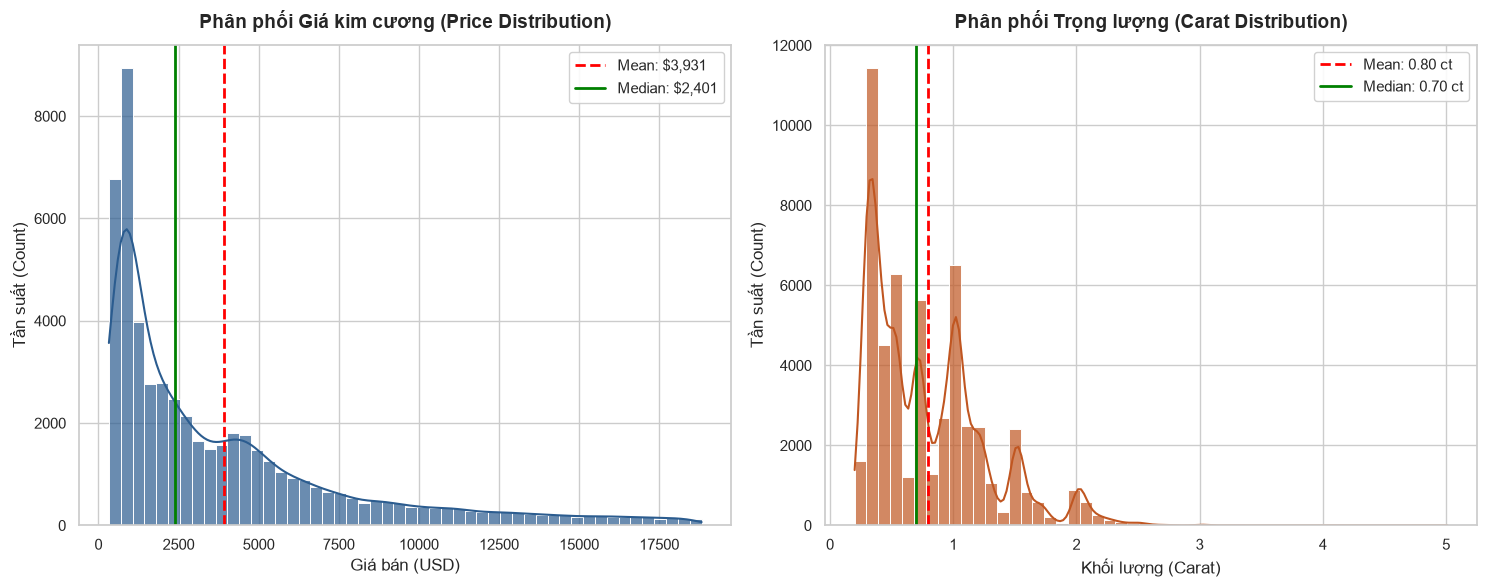

In [12]:
# ==============================================================================
# BIỂU ĐỒ 1: HISTOGRAM KẾT HỢP KDE CHO PRICE VÀ CARAT
# Lý do chọn biểu đồ:
# - Histogram & KDE là công cụ chuẩn xác nhất để mô tả hình dạng phân phối xác suất
#   liên tục của dữ liệu, nhận diện các đỉnh mật độ (multimodal) và độ lệch (skewness).
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Phân phối của biến price
sns.histplot(df_clean['price'], kde=True, color='#2b5c8f', bins=50, ax=axes[0], edgecolor='white', alpha=0.7)
axes[0].axvline(df_clean['price'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: ${df_clean['price'].mean():,.0f}")
axes[0].axvline(df_clean['price'].median(), color='green', linestyle='-', linewidth=2, label=f"Median: ${df_clean['price'].median():,.0f}")
axes[0].set_title("Phân phối Giá kim cương (Price Distribution)", fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel("Giá bán (USD)", fontsize=12)
axes[0].set_ylabel("Tần suất (Count)", fontsize=12)
axes[0].legend(frameon=True, facecolor='white', framealpha=0.9)

# Subplot 2: Phân phối của biến carat
sns.histplot(df_clean['carat'], kde=True, color='#c05621', bins=50, ax=axes[1], edgecolor='white', alpha=0.7)
axes[1].axvline(df_clean['carat'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df_clean['carat'].mean():.2f} ct")
axes[1].axvline(df_clean['carat'].median(), color='green', linestyle='-', linewidth=2, label=f"Median: {df_clean['carat'].median():.2f} ct")
axes[1].set_title("Phân phối Trọng lượng (Carat Distribution)", fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel("Khối lượng (Carat)", fontsize=12)
axes[1].set_ylabel("Tần suất (Count)", fontsize=12)
axes[1].legend(frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
fig_path_1 = os.path.join(FIGURES_DIR, "01_hist_kde_price_carat.png")
plt.savefig(fig_path_1, dpi=300, bbox_inches='tight')
print(f">> [ĐÃ LƯU] Biểu đồ 1 tại: {fig_path_1}")
plt.show()


### Nhận xét Biểu đồ 1:
- **Phân phối thực tế:** Cả hai biến price và carat đều thể hiện rõ rệt đặc tính **lệch phải mạnh (Right-Skewed / Positively Skewed)**. Đa số giao dịch kim cương tập trung ở phân khúc giá phổ thông (< 5,000 USD) và trọng lượng dưới 1.0 carat. Đường Mean (màu đỏ) nằm xa về phía bên phải so với đường Median (màu xanh lá) do bị kéo bởi các viên kim cương cỡ lớn có giá trị cao.
- **Hành vi chế tác thương mại:** Trên biểu đồ carat, xuất hiện hiện tượng **tập trung đột biến (spikes)** tại các mốc số nguyên và bán nguyên như .3, 0.5, 0.7, 1.0, 1.5, 2.0\text{ carat}$. Điều này phản ánh thực tế ngành kim hoàn: thợ chế tác có xu hướng giữ lại trọng lượng để viên đá chạm các mốc carat chuẩn mang lại giá trị thương mại cao hơn.
- *> **Lưu ý chuyển giao Phần 2:** Việc kiểm định thống kê chuyên sâu xem price và carat có tuân theo các phân phối xác suất lý thuyết (chuẩn, log-chuẩn, hàm mũ...) hay không sẽ được bạn Thái Hà phân tích toàn diện và độc lập ở Phần 2.*


### Biểu đồ 2: 
So sánh Phân vị & Ngoại lai của Giá theo Giác cắt và Màu sắc (Boxplot)

>> [ĐÃ LƯU] Biểu đồ 2 tại: ..\figures\part1_eda\02_boxplot_price_by_cut_color.png


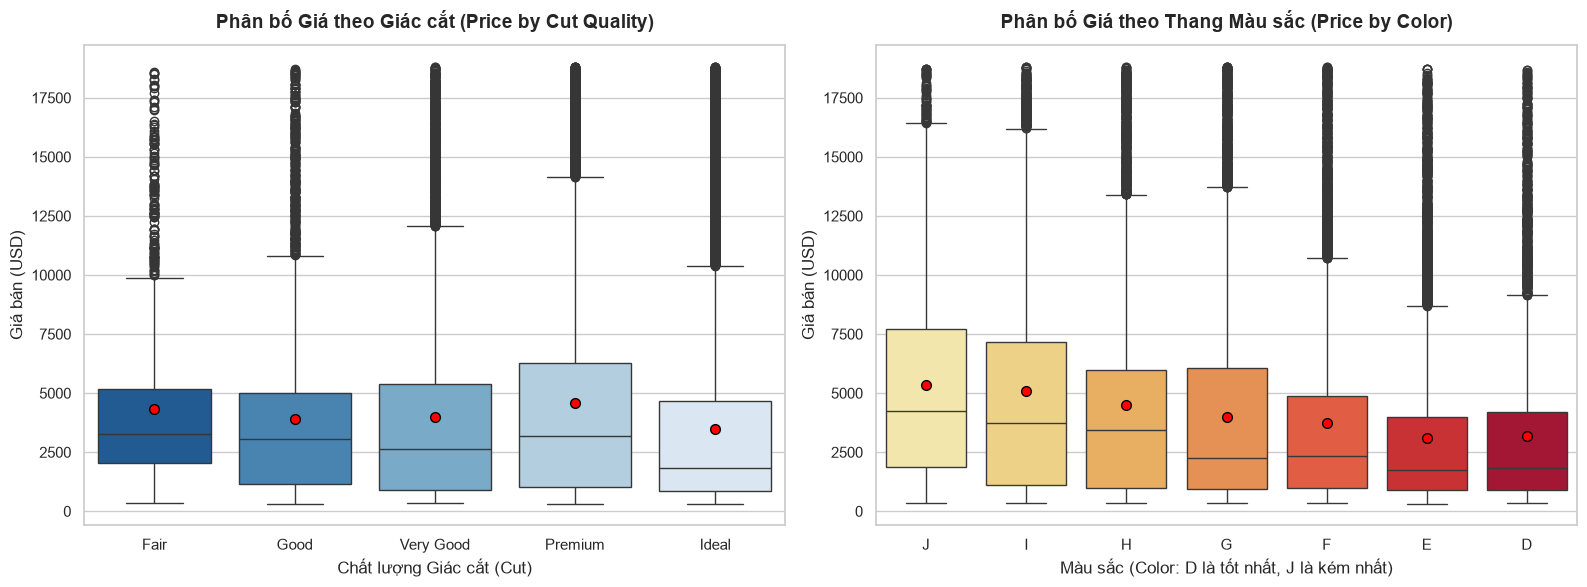

In [13]:
# ==============================================================================
# BIỂU ĐỒ 2: BOXPLOT PHÂN BỐ GIÁ THEO GIÁC CẮT (CUT) VÀ MÀU SẮC (COLOR)
# Lý do chọn biểu đồ:
# - Boxplot thể hiện hoàn hảo cấu trúc 5 số (Min, Q1, Median, Q3, Max) và giúp
#   phát hiện các điểm ngoại lai (outliers) trực quan trên từng nhóm định tính.
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Price theo Cut
sns.boxplot(data=df_clean, x='cut', y='price', palette='Blues_r', ax=axes[0], showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"black", "markersize":"7"})
axes[0].set_title("Phân bố Giá theo Giác cắt (Price by Cut Quality)", fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel("Chất lượng Giác cắt (Cut)", fontsize=12)
axes[0].set_ylabel("Giá bán (USD)", fontsize=12)

# Subplot 2: Price theo Color
sns.boxplot(data=df_clean, x='color', y='price', palette='YlOrRd', ax=axes[1], showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"black", "markersize":"7"})
axes[1].set_title("Phân bố Giá theo Thang Màu sắc (Price by Color)", fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel("Màu sắc (Color: D là tốt nhất, J là kém nhất)", fontsize=12)
axes[1].set_ylabel("Giá bán (USD)", fontsize=12)

plt.tight_layout()
fig_path_2 = os.path.join(FIGURES_DIR, "02_boxplot_price_by_cut_color.png")
plt.savefig(fig_path_2, dpi=300, bbox_inches='tight')
print(f">> [ĐÃ LƯU] Biểu đồ 2 tại: {fig_path_2}")
plt.show()


### Nhận xét Biểu đồ 2 (Khám phá Nghịch lý 4C):
- Một nghịch lý thú vị xuất hiện: Giác cắt `Fair` (kém nhất) lại có trung vị giá cao hơn giác cắt `Ideal` (tốt nhất); màu sắc `J` (kém nhất) lại có mức giá cao hơn màu `D` (tốt nhất).
- **Giải thích căn nguyên kinh tế:** Những viên kim cương có chất lượng giác cắt kém hoặc màu sắc ngả vàng thường chỉ được đưa ra thị trường khi chúng có **kích thước carat rất lớn** (người thợ không muốn cắt nhỏ để giữ trọng lượng). Chính yếu tố khối lượng `carat` áp đảo đã đẩy giá bán của các nhóm này lên cao. Điều này mở ra hướng phân tích đa biến rất giá trị.

### Biểu đồ 3: 
Cấu trúc Tần số và Tỷ trọng các Biến Định tính (Bar Chart / Countplot)

>> [ĐÃ LƯU] Biểu đồ 3 tại: ..\figures\part1_eda\03_countplot_categorical_attributes.png


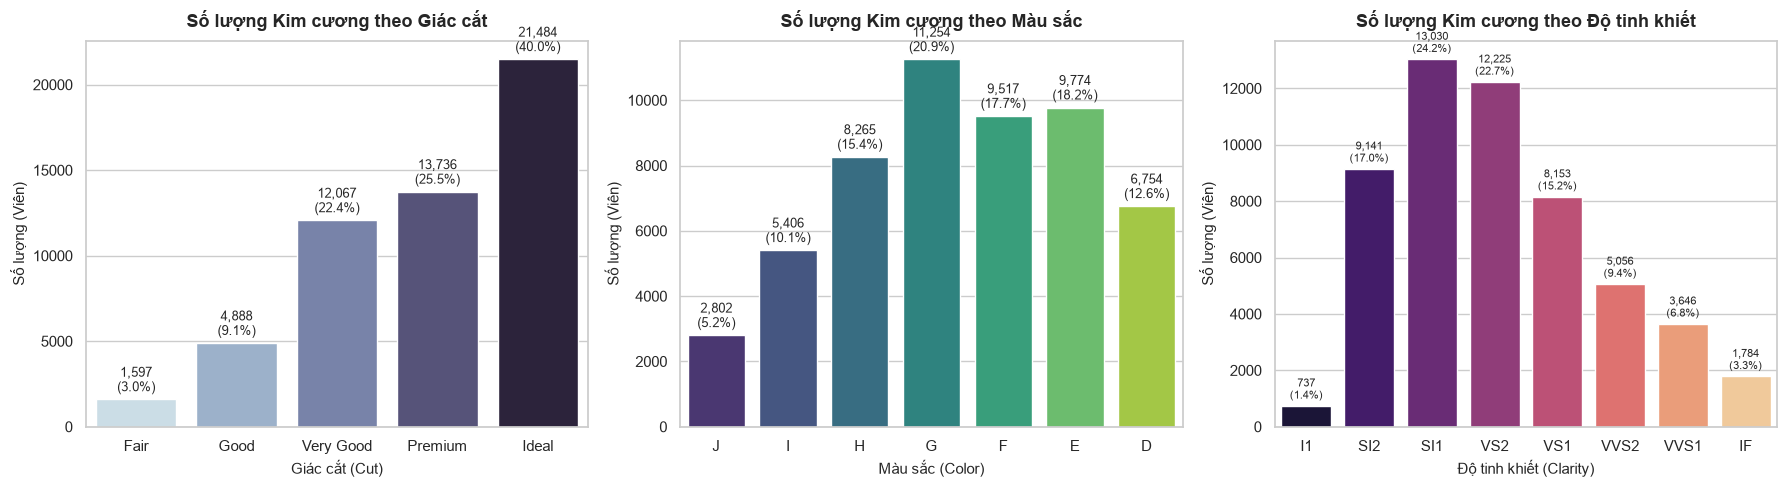

In [14]:
# ==============================================================================
# BIỂU ĐỒ 3: BIỂU ĐỒ CỘT (BAR CHART / COUNTPLOT) CÁC BIẾN ĐỊNH TÍNH (CUT, COLOR, CLARITY)
# Lý do chọn biểu đồ:
# - Bar chart / Countplot là phương pháp tối ưu để hiển thị tần số và tỷ trọng cấu trúc
#   của các biến định tính danh nghĩa và thứ bậc trong mẫu nghiên cứu.
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: Tần số Cut
palette_cut = sns.color_palette("ch:s=.25,rot=-.25", len(cut_order))
sns.countplot(data=df_clean, x='cut', ax=axes[0], palette=palette_cut, order=cut_order)
axes[0].set_title("Số lượng Kim cương theo Giác cắt", fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel("Giác cắt (Cut)", fontsize=11)
axes[0].set_ylabel("Số lượng (Viên)", fontsize=11)
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}\n({p.get_height()/len(df_clean)*100:.1f}%)", 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

# Subplot 2: Tần số Color
palette_color = sns.color_palette("viridis", len(color_order))
sns.countplot(data=df_clean, x='color', ax=axes[1], palette=palette_color, order=color_order)
axes[1].set_title("Số lượng Kim cương theo Màu sắc", fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel("Màu sắc (Color)", fontsize=11)
axes[1].set_ylabel("Số lượng (Viên)", fontsize=11)
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height()):,}\n({p.get_height()/len(df_clean)*100:.1f}%)", 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

# Subplot 3: Tần số Clarity
palette_clarity = sns.color_palette("magma", len(clarity_order))
sns.countplot(data=df_clean, x='clarity', ax=axes[2], palette=palette_clarity, order=clarity_order)
axes[2].set_title("Số lượng Kim cương theo Độ tinh khiết", fontsize=13, fontweight='bold', pad=10)
axes[2].set_xlabel("Độ tinh khiết (Clarity)", fontsize=11)
axes[2].set_ylabel("Số lượng (Viên)", fontsize=11)
for p in axes[2].patches:
    axes[2].annotate(f"{int(p.get_height()):,}\n({p.get_height()/len(df_clean)*100:.1f}%)", 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=8, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
fig_path_3 = os.path.join(FIGURES_DIR, "03_countplot_categorical_attributes.png")
plt.savefig(fig_path_3, dpi=300, bbox_inches='tight')
print(f">> [ĐÃ LƯU] Biểu đồ 3 tại: {fig_path_3}")
plt.show()


### Nhận xét Biểu đồ 3:
- Về giác cắt: Chiếm ưu thế áp đảo là loại `Ideal` (gần $40\%$) và `Premium` ($25.6\%$). Loại giác cắt kém `Fair` chỉ chiếm tỷ trọng khiêm tốn $2.99\%$.
- Về độ tinh khiết: Đa số tập trung ở nhóm trung bình khá `SI1`, `VS2`, `SI2` (chiếm hơn $60\%$ toàn bộ mẫu), phản ánh đúng thực tế nguồn cung thương mại.

## 6. Phát hiện & Phân tích Dữ liệu Ngoại lai (Outlier Detection & Evaluation)

### 6.1. Cơ sở Lý thuyết 2 Phương pháp Phát hiện Ngoại lai:

1. **Phương pháp Khoảng tứ phân vị (Interquartile Range - IQR / Hàng rào Tukey):**
   - Khoảng tứ phân vị: $IQR = Q_3 - Q_1$.
   - Hàng rào dưới (Lower Bound): $L = Q_1 - 1.5 \times IQR$.
   - Hàng rào trên (Upper Bound): $U = Q_3 + 1.5 \times IQR$.
   - Điểm ngoại lai là các giá trị nằm ngoài khoảng $[L, U]$.
   - *Ưu điểm:* Là phương pháp phi tham số (non-parametric), không giả định dữ liệu phải tuân theo phân phối chuẩn, rất bền vững (robust) trước các giá trị cực đoan.

2. **Phương pháp Điểm chuẩn hóa Z-Score:**
   - Công thức: $Z_i = \frac{X_i - \mu}{\sigma}$.
   - Ngưỡng xác định ngoại lai: $|Z_i| > 3$ (dựa theo quy tắc kinh nghiệm $3\sigma$ của phân phối chuẩn, nơi $99.73\%$ dữ liệu tập trung trong khoảng $\pm 3\sigma$).
   - *Ưu điểm:* Dễ tính toán, tuy nhiên dễ bị ảnh hưởng bởi chính các giá trị cực trị làm lệch trung bình $\mu$ và độ lệch chuẩn $\sigma$.

--- BẢNG TỔNG HỢP VÀ SO SÁNH GIÁ TRỊ NGOẠI LAI (IQR VS Z-SCORE) ---


,Biến số,Ngưỡng dưới (IQR),Ngưỡng trên (IQR),Số ngoại lai (IQR),Tỷ lệ IQR (%),Số ngoại lai (Z-Score),Tỷ lệ Z-score (%)
0,carat,-0.5600,2.0000,1867,3.4721,429,0.7978
1,depth,58.7500,64.7500,2523,4.6920,681,1.2665
2,table,51.5000,63.5000,603,1.1214,334,0.6211
3,price,-5608.5000,11883.5000,3519,6.5443,1201,2.2335
4,x,1.9650,9.2850,24,0.0446,35,0.0651
5,y,1.9900,9.2700,20,0.0372,31,0.0577
6,z,1.2300,5.7100,27,0.0502,36,0.0669


>> [ĐÃ LƯU] Biểu đồ ngoại lai tại: ..\figures\part1_eda\04_outliers_boxplots.png


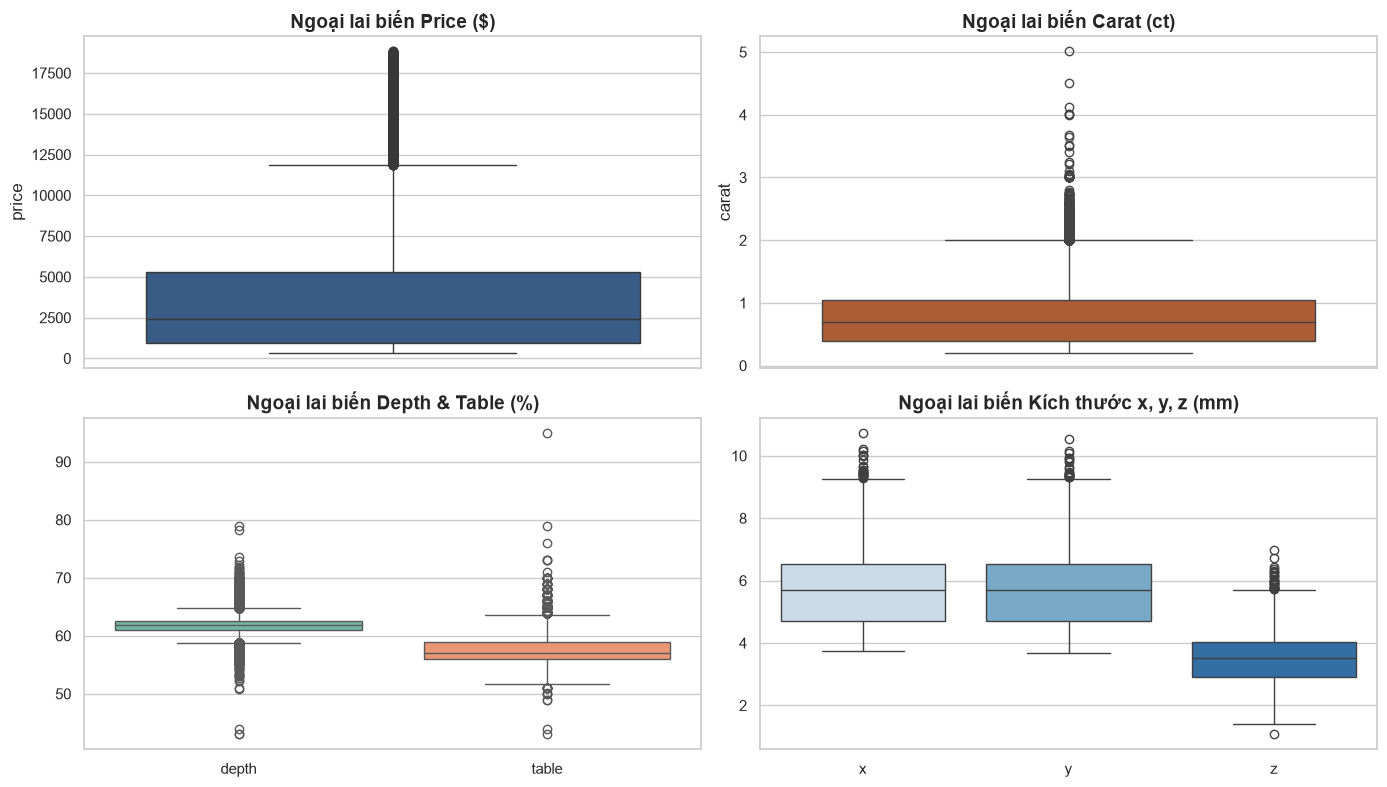

In [15]:
outliers_report = []

for col in num_cols:
    data_col = df_clean[col]
    q1 = data_col.quantile(0.25)
    q3 = data_col.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Ngoại lai theo IQR
    iqr_mask = (data_col < lower_bound) | (data_col > upper_bound)
    n_iqr = int(iqr_mask.sum())
    pct_iqr = (n_iqr / len(df_clean)) * 100
    
    # Ngoại lai theo Z-Score (|Z| > 3)
    z_scores = np.abs(stats.zscore(data_col))
    z_mask = z_scores > 3
    n_z = int(z_mask.sum())
    pct_z = (n_z / len(df_clean)) * 100
    
    outliers_report.append({
        'Biến số': col,
        'Ngưỡng dưới (IQR)': lower_bound,
        'Ngưỡng trên (IQR)': upper_bound,
        'Số ngoại lai (IQR)': n_iqr,
        'Tỷ lệ IQR (%)': pct_iqr,
        'Số ngoại lai (Z-Score)': n_z,
        'Tỷ lệ Z-score (%)': pct_z
    })

outliers_df = pd.DataFrame(outliers_report)
print("--- BẢNG TỔNG HỢP VÀ SO SÁNH GIÁ TRỊ NGOẠI LAI (IQR VS Z-SCORE) ---")
display(outliers_df)

# Trực quan hóa phạm vi ngoại lai bằng Boxplot tổng hợp
plt.figure(figsize=(14, 8))
plt.subplot(2, 2, 1)
sns.boxplot(y=df_clean['price'], color='#2b5c8f')
plt.title("Ngoại lai biến Price ($)", fontweight='bold')

plt.subplot(2, 2, 2)
sns.boxplot(y=df_clean['carat'], color='#c05621')
plt.title("Ngoại lai biến Carat (ct)", fontweight='bold')

plt.subplot(2, 2, 3)
sns.boxplot(data=df_clean[['depth', 'table']], palette='Set2')
plt.title("Ngoại lai biến Depth & Table (%)", fontweight='bold')

plt.subplot(2, 2, 4)
sns.boxplot(data=df_clean[['x', 'y', 'z']], palette='Blues')
plt.title("Ngoại lai biến Kích thước x, y, z (mm)", fontweight='bold')

plt.tight_layout()
fig_path_6 = os.path.join(FIGURES_DIR, "04_outliers_boxplots.png")
plt.savefig(fig_path_6, dpi=300, bbox_inches='tight')
print(f">> [ĐÃ LƯU] Biểu đồ ngoại lai tại: {fig_path_6}")
plt.show()


### 6.2. Đề xuất & Quyết định Phương án Xử lý Ngoại lai (Outlier Evaluation Strategy)

Phân biệt giữa **Ngoại lai dị biệt vi phạm giới hạn vật lý** và **Ngoại lai tự nhiên của nghiệp vụ kinh tế** để quyết định giá trị dự án:

1. **Ngoại lai dị biệt vi phạm giới hạn vật lý (Gross Physical Anomalies):**
   - Đã được phát hiện và xử lý triệt để tại Bước 3:
     - 19 bản ghi có kích thước $x, y, z \le 0$ (vô lý về mặt vật lý học không gian 3 chiều).
     - 3 bản ghi có kích thước $y > 20\text{ mm}$ hoặc $z > 20\text{ mm}$ (mâu thuẫn nghiêm trọng với khối lượng carat và tỷ lệ quang học hình học của viên kim cương).
   - Các trường hợp này đã được **loại bỏ khỏi tập dữ liệu** dựa trên căn cứ khoa học khách quan.

2. **Ngoại lai tự nhiên hợp lệ (Natural Domain-Specific Outliers):**
   - Biến `price` phát hiện $3,519$ điểm ($6.54\%$) vượt ngưỡng $11,885\text{ USD}$.
   - Biến `carat` phát hiện $1,867$ điểm ($3.47\%$) vượt ngưỡng $2.0\text{ carat}$.
   - **Đánh giá bản chất:** Trong thị trường trang sức, những viên kim cương kích thước từ 2 đến 5 carat có giá bán từ 12,000 USD đến 18,800 USD là hoàn toàn có thật. Đây là những sản phẩm xa xỉ cao cấp dành cho tầng lớp thượng lưu, phản ánh đúng quy luật cung cầu của thị trường chứ không phải lỗi dữ liệu.
   - **Quyết định phương án xử lý:** **GIỮ NGUYÊN (RETAIN)** các giá trị ngoại lai tự nhiên này trong tập dữ liệu sạch bàn giao. Việc tùy tiện cắt bỏ (trimming) hay ép biên (winsorization) sẽ làm mất mát thông tin về phân khúc cao cấp, làm sai lệch phân phối xác suất và làm giảm tính chính xác của mô hình dự báo hồi quy.

## 7. Xuất Dữ liệu Đã Làm sạch (Data Export)

Tập dữ liệu hoàn thiện được xuất ra định dạng `.csv` tại thư mục dùng chung `data/processed/cleaned_diamonds.csv`

In [16]:
# Lưu file dữ liệu sạch
df_clean.to_csv(PROCESSED_DATA_PATH, index=False)
print(f">> [THÀNH CÔNG] Đã xuất file dữ liệu sạch tại: {PROCESSED_DATA_PATH}")

# Kiểm tra lại tính toàn vẹn của file vừa xuất
df_verify = pd.read_csv(PROCESSED_DATA_PATH)
print()
print("--- BÁO CÁO NGHIỆM THU TẬP DỮ LIỆU SẠCH DÙNG CHUNG ---")
print(f"- Kích thước file (Shape): {df_verify.shape[0]:,} dòng x {df_verify.shape[1]} cột")
print(f"- Tổng số giá trị thiếu (Missing values): {df_verify.isnull().sum().sum()}")
print(f"- Tổng số dòng trùng lặp (Duplicates): {df_verify.duplicated().sum()}")
print(f"- Dung lượng tập dữ liệu trên đĩa: {os.path.getsize(PROCESSED_DATA_PATH) / 1024:.2f} KB")
print()
print("5 Dòng dữ liệu mẫu sẵn sàng sử dụng:")
display(df_verify.head())


>> [THÀNH CÔNG] Đã xuất file dữ liệu sạch tại: ..\data\processed\cleaned_diamonds.csv

--- BÁO CÁO NGHIỆM THU TẬP DỮ LIỆU SẠCH DÙNG CHUNG ---
- Kích thước file (Shape): 53,772 dòng x 10 cột
- Tổng số giá trị thiếu (Missing values): 0
- Tổng số dòng trùng lặp (Duplicates): 0
- Dung lượng tập dữ liệu trên đĩa: 2556.45 KB

5 Dòng dữ liệu mẫu sẵn sàng sử dụng:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.2300,Ideal,E,SI2,61.5000,55.0000,326,3.9500,3.9800,2.4300
1,0.2100,Premium,E,SI1,59.8000,61.0000,326,3.8900,3.8400,2.3100
2,0.2300,Good,E,VS1,56.9000,65.0000,327,4.0500,4.0700,2.3100
3,0.2900,Premium,I,VS2,62.4000,58.0000,334,4.2000,4.2300,2.6300
4,0.3100,Good,J,SI2,63.3000,58.0000,335,4.3400,4.3500,2.7500


## 8. Tổng kết & Nhận xét Tổng quan Tập Dữ liệu (Executive Summary & Team Handover)

---

### 5 Phát hiện Nổi bật (Key Insights) từ Quá trình EDA:
1. **Chất lượng dữ liệu đạt chuẩn hoàn hảo:** Toàn bộ 53,772 bản ghi sạch (100% không khuyết thiếu sau khi xử lý loại bỏ 146 dòng trùng lặp và 22 dị biệt phi lý vật lý , y, z \le 0$ hoặc kích thước bất thường $>20\text{ mm}$).
2. **Đặc trưng phân bố lệch phải của Giá (price) và Khối lượng (carat):** Phần lớn sản phẩm tập trung ở phân khúc phổ thông (< 5,000 USD và < 1.0 ct), trong khi đuôi phân phối kéo dài phản ánh các dòng kim cương cao cấp xa xỉ.
3. **Ưu thế tuyệt đối của kỹ thuật chế tác cao cấp:** Hơn .5\%$ kim cương trong tập dữ liệu đạt giác cắt chất lượng cao (Ideal và Premium), phản ánh tiêu chuẩn chế tác thương mại ưu tiên tối ưu hóa độ tán sắc ánh sáng.
4. **Nghịch lý 4C trong phân tích phân nhóm:** Giác cắt kém hơn (Fair) và màu sắc ngả vàng hơn (J) có mức giá trung vị cao hơn một số nhóm cao cấp (Ideal, D), do các viên này trong thực tế có kích thước carat trung bình lớn hơn đáng kể (yếu tố trọng lượng lấn át phẩm cấp).
5. **Chiến lược bảo toàn ngoại lai tự nhiên hợp lệ:** Toàn bộ các quan sát giá cao và carat lớn được giữ nguyên vẹn trong tập dữ liệu sạch, đảm bảo không làm méo mó bản chất của thị trường hàng xa xỉ và cung cấp dữ liệu trung thực cho các phần kiểm định, tương quan và mô hình hóa tiếp theo.

---
